In [1]:
import torch
import torch.nn as nn
import torch.optim as opt

import h_util

torch.manual_seed(42)

In [2]:
d = torch.tensor([[1.0],[2.0],[3.0],[4.0]], dtype=torch.float32)
t = torch.tensor([[6.96],[12.11],[16.77],[22.21]], dtype=torch.float32)

In [3]:
model = nn.Sequential(nn.Linear(1,1))

In [4]:
loss_funck = nn.MSELoss()
optimiser = opt.SGD(model.parameters(), lr=0.01)

In [5]:
for epoch in range(500):
    optimiser.zero_grad()
    out = model(d)
    loss = loss_funck(out,t)
    loss.backward()
    optimiser.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}: Loss = {loss.item()}")

Epoch 50: Loss = 0.03944866359233856
Epoch 100: Loss = 0.03581171855330467
Epoch 150: Loss = 0.03311903774738312
Epoch 200: Loss = 0.03112369030714035
Epoch 250: Loss = 0.02964562550187111
Epoch 300: Loss = 0.02855011820793152
Epoch 350: Loss = 0.0277385413646698
Epoch 400: Loss = 0.027137158438563347
Epoch 450: Loss = 0.026691768318414688
Epoch 500: Loss = 0.026361485943198204


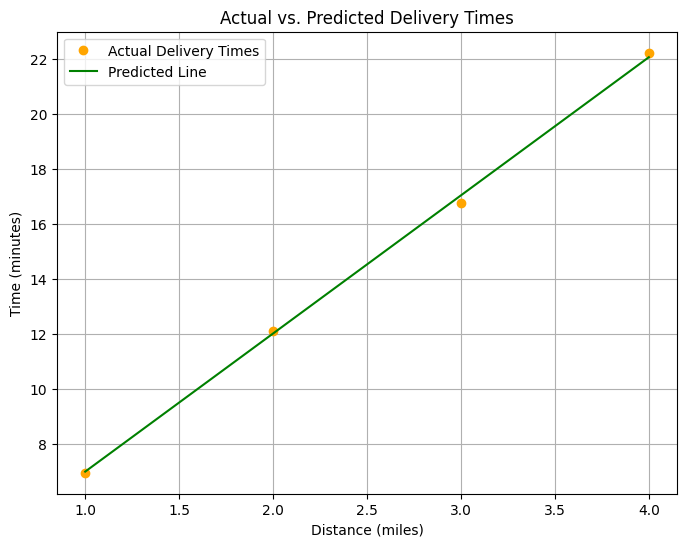

In [6]:
h_util.plot_results(model,d,t)

In [7]:
d_pred = 7.0

In [8]:
with torch.no_grad():
    new_d = torch.tensor([[d_pred]], dtype=torch.float32)
    
    pred_t = model(new_d)
    
    print(f"Predicted time for a distance of {new_d} is {pred_t.item():.1f} minutes")
    
    if pred_t.item() > 30:
        print("\nDecision : Do NOT take this JOB")
    else:
        print("\nDecision : Take the JOB")

Predicted time for a distance of tensor([[7.]]) is 37.1 minutes

Decision : Do NOT take this JOB


In [9]:
layer = model[0]

w = layer.weight.data.numpy()
b = layer.bias.data.numpy()

print(f"Weight : {w}")
print(f"Bias : {b}")

Weight : [[5.015503]]
Bias : [1.9849643]


In [10]:
more_d = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

more_t = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

In [11]:
with torch.no_grad():
    pred_more_t = model(more_d)
    
    for i in range(len(more_d)):
        print(f"Distance: {more_d[i].item():.1f} km, Actual Time: {more_t[i].item():.2f} min, Predicted Time: {pred_more_t[i].item():.2f} min")

Distance: 1.0 km, Actual Time: 6.96 min, Predicted Time: 7.00 min
Distance: 1.5 km, Actual Time: 9.67 min, Predicted Time: 9.51 min
Distance: 2.0 km, Actual Time: 12.11 min, Predicted Time: 12.02 min
Distance: 2.5 km, Actual Time: 14.56 min, Predicted Time: 14.52 min
Distance: 3.0 km, Actual Time: 16.77 min, Predicted Time: 17.03 min
Distance: 3.5 km, Actual Time: 21.70 min, Predicted Time: 19.54 min
Distance: 4.0 km, Actual Time: 26.52 min, Predicted Time: 22.05 min
Distance: 4.5 km, Actual Time: 32.47 min, Predicted Time: 24.55 min
Distance: 5.0 km, Actual Time: 37.15 min, Predicted Time: 27.06 min
Distance: 5.5 km, Actual Time: 42.35 min, Predicted Time: 29.57 min
Distance: 6.0 km, Actual Time: 46.10 min, Predicted Time: 32.08 min
Distance: 6.5 km, Actual Time: 52.98 min, Predicted Time: 34.59 min
Distance: 7.0 km, Actual Time: 57.76 min, Predicted Time: 37.09 min
Distance: 7.5 km, Actual Time: 61.29 min, Predicted Time: 39.60 min
Distance: 8.0 km, Actual Time: 66.15 min, Predicted 

In [12]:
more_loss = loss_funck(pred_more_t, more_t)
print(f"Loss on new, combined data: {more_loss.item():.2f}")

Loss on new, combined data: 179.26


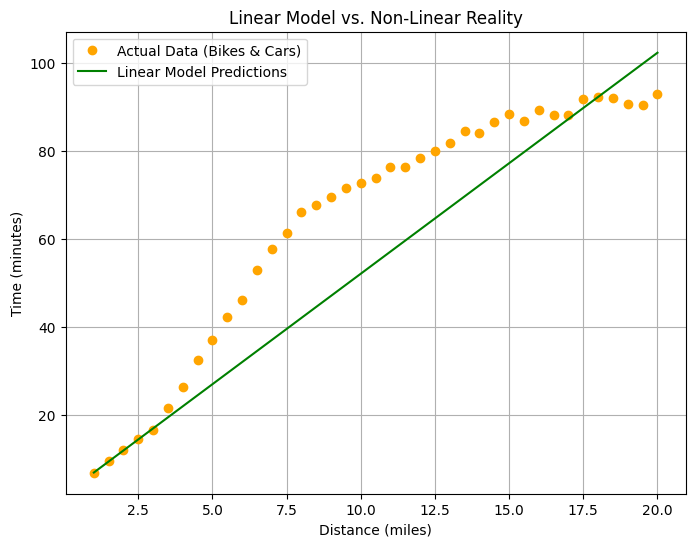

In [13]:
h_util.plot_nonlinear_comparison(model, more_d, more_t)